In [ ]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
pip install matplotlib

In [ ]:
pip install scikit-learn

In [1]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import classification_report
import numpy as np

In [2]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## Carregamento do dataset

Escolha **apenas uma** das opções abaixo:

- **Opção A — Google Drive:** mais rápida quando o arquivo `IRT_Motor.zip` já está salvo no Drive.
- **Opção B — Upload local:** permite selecionar o ZIP diretamente no computador.

Por padrão, `USE_GOOGLE_DRIVE = True`. Para usar o upload local, altere para `False`.


In [4]:
from pathlib import Path
import zipfile

USE_GOOGLE_DRIVE = True  # True: usa Drive | False: usa upload local

# Ajuste somente este caminho se o ZIP estiver em outra pasta do Drive.
DRIVE_ZIP_PATH = Path("/content/drive/MyDrive/IRT_Motor.zip")
EXTRACT_ROOT = Path("/content/motor_dataset")
DATASET_PATH = EXTRACT_ROOT / "IRT_Motor"

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    if not DRIVE_ZIP_PATH.exists():
        raise FileNotFoundError(
            f"ZIP não encontrado em: {DRIVE_ZIP_PATH}\n"
            "Ajuste DRIVE_ZIP_PATH para o local correto no Google Drive."
        )

    # Evita extrair novamente quando a pasta já existe e contém dados.
    class_dirs = [p for p in DATASET_PATH.glob("*") if p.is_dir()]

    if len(class_dirs) == 6:
        print("Dataset já extraído. A extração foi ignorada.")
    else:
        EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
        print("Extraindo o dataset do Google Drive...")

        with zipfile.ZipFile(DRIVE_ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(EXTRACT_ROOT)

        print("Extração concluída.")

    print("Dataset disponível em:", DATASET_PATH)
else:
    print("Opção Google Drive desativada. Execute a célula de upload local abaixo.")

Mounted at /content/drive
Extraindo o dataset do Google Drive...
Extração concluída.
Dataset disponível em: /content/motor_dataset/IRT_Motor


In [ ]:
# ============================================================
# OPÇÃO B — UPLOAD E EXTRAÇÃO DO DATASET ZIP
# Execute somente quando USE_GOOGLE_DRIVE = False
# ============================================================

from google.colab import files
from pathlib import Path
import zipfile

if not USE_GOOGLE_DRIVE:
    uploaded = files.upload()

    if not uploaded:
        raise RuntimeError("Nenhum arquivo foi enviado.")

    ZIP_FILE = Path(next(iter(uploaded.keys())))
    EXTRACT_ROOT = Path("/content/motor_dataset")
    DATASET_PATH = EXTRACT_ROOT / "IRT_Motor"

    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_ROOT)

    print("Dataset extraído em:", EXTRACT_ROOT)
    print("Dataset disponível em:", DATASET_PATH)
else:
    print("Upload local ignorado porque USE_GOOGLE_DRIVE = True.")


In [5]:
# ============================================================
# VALIDAR O CAMINHO DO DATASET
# ============================================================

from pathlib import Path

DATASET_PATH = Path(DATASET_PATH)

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Pasta do dataset não encontrada: {DATASET_PATH}")

print("Caminho do dataset:", DATASET_PATH)


Caminho do dataset: /content/motor_dataset/IRT_Motor


In [6]:
# ============================================================
# VERIFICAR CLASSES E QUANTIDADE DE IMAGENS
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

total_images = 0
class_directories = [p for p in sorted(DATASET_PATH.iterdir()) if p.is_dir()]

print("Classes encontradas:")

for class_dir in class_directories:
    image_count = sum(
        1 for file in class_dir.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )
    total_images += image_count
    print(f"{class_dir.name}: {image_count} imagens")

print(f"Total: {total_images} imagens")

if len(class_directories) != 6:
    raise ValueError(
        f"Esperavam-se 6 classes, mas foram encontradas {len(class_directories)}."
    )


Classes encontradas:
Bearing_Failure: 255 imagens
Blocked_Rotor: 275 imagens
Lack_of_Phase: 289 imagens
Normal: 217 imagens
Overheating: 417 imagens
Ventilation_Defect: 326 imagens
Total: 1779 imagens


In [ ]:
# dataset_name = "./IRT_Motor"

# image_size = 64

# transform = transforms.Compose([
#     transforms.Resize((image_size, image_size)),
#     transforms.ToTensor(),
# ])

# dataset = torchvision.datasets.ImageFolder(root=dataset_name, transform=transform)


In [ ]:
# len(dataset)


In [7]:
# ============================================================
# DATASET SETUP — HOLD-OUT TEST + 5-FOLD TRAINING
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from torchvision import datasets, transforms

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------

DATASET_PATH = Path(DATASET_PATH)

# ------------------------------------------------------------
# Image transforms
# Mantém 64x64, conforme o protocolo experimental anterior
# ------------------------------------------------------------

base_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Dataset completo
full_dataset = datasets.ImageFolder(
    root=str(DATASET_PATH),
    transform=base_transform
)

class_names = full_dataset.classes
targets = np.array(full_dataset.targets)
all_indices = np.arange(len(full_dataset))

print("Classes:", class_names)
print("Total de imagens:", len(full_dataset))
print("Mapeamento:", full_dataset.class_to_idx)


Classes: ['Bearing_Failure', 'Blocked_Rotor', 'Lack_of_Phase', 'Normal', 'Overheating', 'Ventilation_Defect']
Total de imagens: 1779
Mapeamento: {'Bearing_Failure': 0, 'Blocked_Rotor': 1, 'Lack_of_Phase': 2, 'Normal': 3, 'Overheating': 4, 'Ventilation_Defect': 5}


In [8]:
# ============================================================
# STRATIFIED HOLD-OUT SPLIT
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 500

# Proporção equivalente a 500 imagens dentro de 1779
test_fraction = TEST_SIZE / len(full_dataset)

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=test_fraction,
    stratify=targets,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_targets = targets[train_indices]
test_targets = targets[test_indices]

print(f"Treinamento/validação: {len(train_indices)} imagens")
print(f"Teste hold-out: {len(test_indices)} imagens")


Treinamento/validação: 1279 imagens
Teste hold-out: 500 imagens


In [9]:
# ============================================================
# VERIFY CLASS DISTRIBUTION
# ============================================================

def class_distribution(indices, targets, class_names):
    subset_targets = targets[indices]

    rows = []

    for class_idx, class_name in enumerate(class_names):
        count = int(np.sum(subset_targets == class_idx))

        rows.append({
            "class": class_name,
            "count": count
        })

    return pd.DataFrame(rows)


train_distribution = class_distribution(
    train_indices,
    targets,
    class_names
)

test_distribution = class_distribution(
    test_indices,
    targets,
    class_names
)

print("Distribuição — treinamento/validação")
display(train_distribution)

print("Distribuição — teste hold-out")
display(test_distribution)


Distribuição — treinamento/validação


,class,count
0,Bearing_Failure,183
1,Blocked_Rotor,198
2,Lack_of_Phase,208
3,Normal,156
4,Overheating,300
5,Ventilation_Defect,234


Distribuição — teste hold-out


,class,count
0,Bearing_Failure,72
1,Blocked_Rotor,77
2,Lack_of_Phase,81
3,Normal,61
4,Overheating,117
5,Ventilation_Defect,92


In [10]:
# ============================================================
# STRATIFIED 5-FOLD CROSS-VALIDATION
# Applied only to the training partition
# ============================================================

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_splits = []

for fold_number, (fold_train_pos, fold_val_pos) in enumerate(
    skf.split(train_indices, train_targets),
    start=1
):
    fold_train_indices = train_indices[fold_train_pos]
    fold_val_indices = train_indices[fold_val_pos]

    fold_splits.append({
        "fold": fold_number,
        "train_indices": fold_train_indices,
        "val_indices": fold_val_indices
    })

    print(
        f"Fold {fold_number}: "
        f"{len(fold_train_indices)} treino | "
        f"{len(fold_val_indices)} validação"
    )


Fold 1: 1023 treino | 256 validação
Fold 2: 1023 treino | 256 validação
Fold 3: 1023 treino | 256 validação
Fold 4: 1023 treino | 256 validação
Fold 5: 1024 treino | 255 validação


In [11]:
# batch_size = 256
# test_size = 500
# train_size = len(dataset) - test_size

# train_data,test_data = random_split(dataset,[train_size,test_size])
# print(f"Length of Train Data : {len(train_data)}")
# print(f"Length of Test Data : {len(test_data)}")


In [12]:
# ============================================================
# DATALOADER CONFIGURATION
# ============================================================

import torch
from torch.utils.data import DataLoader, Subset

BATCH_SIZE = 256
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

def create_fold_loaders(
    dataset,
    fold_train_indices,
    fold_val_indices,
    batch_size=BATCH_SIZE
):
    train_subset = Subset(dataset, fold_train_indices)
    val_subset = Subset(dataset, fold_val_indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    return train_loader, val_loader


test_subset = Subset(full_dataset, test_indices)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Test loader criado com sucesso.")
print("Número de batches de teste:", len(test_loader))


Test loader criado com sucesso.
Número de batches de teste: 2


In [13]:
first_fold = fold_splits[0]

train_loader, val_loader = create_fold_loaders(
    full_dataset,
    first_fold["train_indices"],
    first_fold["val_indices"]
)

print("Fold 1")
print("Imagens de treino:", len(train_loader.dataset))
print("Imagens de validação:", len(val_loader.dataset))
print("Batches de treino:", len(train_loader))
print("Batches de validação:", len(val_loader))


Fold 1
Imagens de treino: 1023
Imagens de validação: 256
Batches de treino: 4
Batches de validação: 1


Agora vamos preparar a ShuffleNet V2 reinicializada em cada fold. Isso é essencial: cada fold precisa começar com o mesmo tipo de inicialização, sem carregar pesos aprendidos no fold anterior.


In [14]:
# ============================================================
# SHUFFLENET V2 MODEL FACTORY
# ============================================================

from torchvision import models
import torch.nn as nn

NUM_CLASSES = len(class_names)

def create_shufflenet_model(num_classes=NUM_CLASSES):

    weights = models.ShuffleNet_V2_X0_5_Weights.DEFAULT

    model = models.shufflenet_v2_x0_5(weights=weights)

    # Congela todas as camadas
    for param in model.parameters():
        param.requires_grad = False

    # Substitui somente a camada final
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)

# Teste de criação
model_test = create_shufflenet_model()

print(model_test.__class__.__name__)
print("Número de classes:", model_test.fc.out_features)
print("Dispositivo:", next(model_test.parameters()).device)


Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth


100%|██████████| 5.28M/5.28M [00:00<00:00, 61.1MB/s]


ShuffleNetV2
Número de classes: 6
Dispositivo: cuda:0


In [ ]:
# #load the train and test into batches.
# train_dl = DataLoader(train_data, batch_size, shuffle = True)
# test_dl = DataLoader(test_data, batch_size)


In [15]:
# ============================================================
# FORWARD-PASS TEST
# ============================================================

model_test = create_shufflenet_model()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model_test(images)
    probabilities = torch.softmax(logits, dim=1)

print("Shape das imagens:", images.shape)
print("Shape dos logits:", logits.shape)
print("Shape das probabilidades:", probabilities.shape)
print(
    "Soma das probabilidades da primeira imagem:",
    probabilities[0].sum().item()
)


Shape das imagens: torch.Size([256, 3, 64, 64])
Shape dos logits: torch.Size([256, 6])
Shape das probabilidades: torch.Size([256, 6])
Soma das probabilidades da primeira imagem: 1.0


In [17]:
# ============================================================
# TRAINING AND VALIDATION FUNCTIONS
# ============================================================

import numpy as np
import torch
from sklearn.metrics import accuracy_score


def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct_predictions += (
            logits.argmax(dim=1) == labels
        ).sum().item()

        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


@torch.no_grad()
def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

    y_true = np.asarray(all_labels)
    y_pred = np.asarray(all_predictions)
    y_prob = np.asarray(all_probabilities)

    return {
        "loss": running_loss / total_samples,
        "accuracy": accuracy_score(y_true, y_pred),
        "labels": y_true,
        "predictions": y_pred,
        "probabilities": y_prob
    }

In [18]:
print("train_one_epoch:", callable(train_one_epoch))
print("validate_one_epoch:", callable(validate_one_epoch))

train_one_epoch: True
validate_one_epoch: True


In [19]:
# ============================================================
# STRATIFIED 5-FOLD CROSS-VALIDATION TRAINING
# ============================================================

import copy
import random
import time
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Experimental configuration
# ------------------------------------------------------------

NUM_EPOCHS = 100
LEARNING_RATE = 0.001
RANDOM_STATE = 42

CHECKPOINT_DIR = Path("/content/shufflenet_5fold_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducibilidade adicional
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# Containers
# ------------------------------------------------------------

fold_results = []
fold_histories = []

best_global_accuracy = -1.0
best_global_fold = None
best_global_checkpoint = None


# ------------------------------------------------------------
# Five-fold training
# ------------------------------------------------------------

for fold_data in fold_splits:

    fold_number = fold_data["fold"]

    print("\n" + "=" * 70)
    print(f"FOLD {fold_number}/{N_SPLITS}")
    print("=" * 70)

    # A mesma inicialização controlada em cada fold
    set_seed(RANDOM_STATE + fold_number)

    # DataLoaders do fold atual
    train_loader, val_loader = create_fold_loaders(
        full_dataset,
        fold_data["train_indices"],
        fold_data["val_indices"]
    )

    # Nova ShuffleNet para cada fold
    model = create_shufflenet_model()

    # Apenas os parâmetros treináveis, isto é, a camada FC
    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        trainable_parameters,
        lr=LEARNING_RATE
    )

    print("Imagens de treino:", len(train_loader.dataset))
    print("Imagens de validação:", len(val_loader.dataset))
    print(
        "Parâmetros treináveis:",
        sum(parameter.numel() for parameter in trainable_parameters)
    )

    best_val_accuracy = -1.0
    best_epoch = 0
    best_state_dict = None
    best_validation_output = None

    history_rows = []

    fold_start_time = time.time()

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(1, NUM_EPOCHS + 1):

        epoch_start_time = time.time()

        train_loss, train_accuracy = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        validation_output = validate_one_epoch(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device
        )

        val_loss = validation_output["loss"]
        val_accuracy = validation_output["accuracy"]

        epoch_time = time.time() - epoch_start_time

        history_rows.append({
            "fold": fold_number,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "epoch_time_seconds": epoch_time
        })

        # Salva em memória o melhor estado do fold
        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy
            best_epoch = epoch

            best_state_dict = copy.deepcopy(
                model.state_dict()
            )

            best_validation_output = {
                key: (
                    value.copy()
                    if isinstance(value, np.ndarray)
                    else value
                )
                for key, value in validation_output.items()
            }

        # Impressão controlada
        if (
            epoch == 1
            or epoch % 10 == 0
            or epoch == NUM_EPOCHS
        ):
            print(
                f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_accuracy:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_accuracy:.4f}"
            )

    fold_total_time = time.time() - fold_start_time

    # --------------------------------------------------------
    # Restore best fold checkpoint
    # --------------------------------------------------------

    model.load_state_dict(best_state_dict)

    y_true = best_validation_output["labels"]
    y_pred = best_validation_output["predictions"]
    y_prob = best_validation_output["probabilities"]

    # Confiança da classe efetivamente prevista
    predicted_confidences = y_prob.max(axis=1)

    # --------------------------------------------------------
    # Fold metrics
    # --------------------------------------------------------

    fold_accuracy = accuracy_score(y_true, y_pred)

    fold_precision_macro = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    fold_recall_macro = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    fold_f1_macro = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    mean_confidence = float(
        np.mean(predicted_confidences)
    )

    std_confidence = float(
        np.std(predicted_confidences, ddof=1)
    )

    fold_result = {
        "fold": fold_number,
        "best_epoch": best_epoch,
        "accuracy": fold_accuracy,
        "precision_macro": fold_precision_macro,
        "recall_macro": fold_recall_macro,
        "f1_macro": fold_f1_macro,
        "mean_predicted_confidence": mean_confidence,
        "std_predicted_confidence": std_confidence,
        "training_time_seconds": fold_total_time,
        "train_samples": len(train_loader.dataset),
        "validation_samples": len(val_loader.dataset)
    }

    fold_results.append(fold_result)

    fold_history_df = pd.DataFrame(history_rows)
    fold_histories.append(fold_history_df)

    # --------------------------------------------------------
    # Save checkpoint
    # --------------------------------------------------------

    fold_checkpoint_path = (
        CHECKPOINT_DIR /
        f"shufflenet_v2_x0_5_fold_{fold_number}.pth"
    )

    torch.save(
        {
            "fold": fold_number,
            "best_epoch": best_epoch,
            "model_state_dict": best_state_dict,
            "class_names": class_names,
            "class_to_idx": full_dataset.class_to_idx,
            "validation_accuracy": fold_accuracy,
            "validation_precision_macro": fold_precision_macro,
            "validation_recall_macro": fold_recall_macro,
            "validation_f1_macro": fold_f1_macro,
            "mean_predicted_confidence": mean_confidence,
            "image_size": [64, 64],
            "architecture": "shufflenet_v2_x0_5",
            "pretrained_weights": "ImageNet",
            "frozen_feature_extractor": True
        },
        fold_checkpoint_path
    )

    # Salva também as probabilidades do fold
    probability_df = pd.DataFrame(
        y_prob,
        columns=[
            f"probability_{class_name}"
            for class_name in class_names
        ]
    )

    probability_df.insert(
        0,
        "true_class",
        [class_names[index] for index in y_true]
    )

    probability_df.insert(
        1,
        "predicted_class",
        [class_names[index] for index in y_pred]
    )

    probability_df.insert(
        2,
        "predicted_confidence",
        predicted_confidences
    )

    probability_df.to_csv(
        CHECKPOINT_DIR /
        f"fold_{fold_number}_validation_predictions.csv",
        index=False
    )

    fold_history_df.to_csv(
        CHECKPOINT_DIR /
        f"fold_{fold_number}_history.csv",
        index=False
    )

    print("\nMelhor resultado do fold")
    print(f"Epoch: {best_epoch}")
    print(f"Accuracy: {fold_accuracy:.4f}")
    print(f"Macro Precision: {fold_precision_macro:.4f}")
    print(f"Macro Recall: {fold_recall_macro:.4f}")
    print(f"Macro F1: {fold_f1_macro:.4f}")
    print(
        f"Confidence: "
        f"{mean_confidence:.4f} ± {std_confidence:.4f}"
    )
    print("Checkpoint:", fold_checkpoint_path)

    # --------------------------------------------------------
    # Track global best fold
    # --------------------------------------------------------

    if fold_accuracy > best_global_accuracy:

        best_global_accuracy = fold_accuracy
        best_global_fold = fold_number
        best_global_checkpoint = fold_checkpoint_path


# ============================================================
# CONSOLIDATED FIVE-FOLD RESULTS
# ============================================================

fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

fold_results_df.to_csv(
    CHECKPOINT_DIR / "five_fold_results.csv",
    index=False
)

all_fold_histories_df = pd.concat(
    fold_histories,
    ignore_index=True
)

all_fold_histories_df.to_csv(
    CHECKPOINT_DIR / "five_fold_training_history.csv",
    index=False
)


# ------------------------------------------------------------
# Mean ± standard deviation
# ------------------------------------------------------------

metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "mean_predicted_confidence"
]

summary_rows = []

for metric in metric_columns:

    values = fold_results_df[metric].astype(float)

    summary_rows.append({
        "metric": metric,
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "min": values.min(),
        "max": values.max()
    })

five_fold_summary_df = pd.DataFrame(summary_rows)

display(five_fold_summary_df)

five_fold_summary_df.to_csv(
    CHECKPOINT_DIR / "five_fold_summary.csv",
    index=False
)

print("\n" + "=" * 70)
print("FINAL FIVE-FOLD SUMMARY")
print("=" * 70)

for _, row in five_fold_summary_df.iterrows():
    print(
        f"{row['metric']}: "
        f"{row['mean']:.4f} ± {row['std']:.4f}"
    )

print("\nMelhor fold:", best_global_fold)
print("Melhor validation accuracy:", f"{best_global_accuracy:.4f}")
print("Melhor checkpoint:", best_global_checkpoint)
print("\nResultados salvos em:", CHECKPOINT_DIR)



FOLD 1/5
Imagens de treino: 1023
Imagens de validação: 256
Parâmetros treináveis: 6150
Epoch 001/100 | Train Loss: 1.7660 | Train Acc: 0.3832 | Val Loss: 1.7825 | Val Acc: 0.3438
Epoch 010/100 | Train Loss: 1.2818 | Train Acc: 0.9384 | Val Loss: 1.3740 | Val Acc: 0.8945
Epoch 020/100 | Train Loss: 0.9246 | Train Acc: 0.9746 | Val Loss: 0.9157 | Val Acc: 0.9805
Epoch 030/100 | Train Loss: 0.6953 | Train Acc: 0.9863 | Val Loss: 0.6954 | Val Acc: 0.9883
Epoch 040/100 | Train Loss: 0.5513 | Train Acc: 0.9853 | Val Loss: 0.5494 | Val Acc: 0.9883
Epoch 050/100 | Train Loss: 0.4461 | Train Acc: 0.9892 | Val Loss: 0.4502 | Val Acc: 0.9883
Epoch 060/100 | Train Loss: 0.3785 | Train Acc: 0.9892 | Val Loss: 0.3775 | Val Acc: 0.9961
Epoch 070/100 | Train Loss: 0.3212 | Train Acc: 0.9932 | Val Loss: 0.3237 | Val Acc: 1.0000
Epoch 080/100 | Train Loss: 0.2875 | Train Acc: 0.9932 | Val Loss: 0.2809 | Val Acc: 1.0000
Epoch 090/100 | Train Loss: 0.2471 | Train Acc: 0.9932 | Val Loss: 0.2472 | Val Acc:

,fold,best_epoch,accuracy,precision_macro,recall_macro,f1_macro,mean_predicted_confidence,std_predicted_confidence,training_time_seconds,train_samples,validation_samples
0,1,68,1.000000,1.000000,1.000000,1.000000,0.741902,0.177583,834.326567,1023,256
1,2,38,0.992188,0.992142,0.990559,0.991234,0.602856,0.179973,824.482011,1023,256
2,3,35,0.996094,0.996528,0.996032,0.996238,0.565898,0.170544,841.037848,1023,256
3,4,100,0.992188,0.993392,0.992180,0.992705,0.823024,0.156851,849.868520,1023,256
4,5,49,0.984314,0.987064,0.983822,0.985022,0.659643,0.186428,834.097000,1024,255


,metric,mean,std,min,max
0,accuracy,0.992956,0.005817,0.984314,1.000000
1,precision_macro,0.993825,0.004852,0.987064,1.000000
2,recall_macro,0.992518,0.006081,0.983822,1.000000
3,f1_macro,0.993040,0.005620,0.985022,1.000000
4,mean_predicted_confidence,0.678665,0.104479,0.565898,0.823024



FINAL FIVE-FOLD SUMMARY
accuracy: 0.9930 ± 0.0058
precision_macro: 0.9938 ± 0.0049
recall_macro: 0.9925 ± 0.0061
f1_macro: 0.9930 ± 0.0056
mean_predicted_confidence: 0.6787 ± 0.1045

Melhor fold: 1
Melhor validation accuracy: 1.0000
Melhor checkpoint: /content/shufflenet_5fold_checkpoints/shufflenet_v2_x0_5_fold_1.pth

Resultados salvos em: /content/shufflenet_5fold_checkpoints


In [20]:
import shutil
from google.colab import files

archive_path = shutil.make_archive(
    "/content/shufflenet_5fold_checkpoints",
    "zip",
    "/content/shufflenet_5fold_checkpoints"
)

print("Arquivo gerado:", archive_path)
files.download(archive_path)

Arquivo gerado: /content/shufflenet_5fold_checkpoints.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,fold,best_epoch,accuracy,precision_macro,recall_macro,f1_macro,mean_predicted_confidence,std_predicted_confidence,training_time_seconds,train_samples,validation_samples
0,1,68,1.000000,1.000000,1.000000,1.000000,0.741902,0.177583,834.326567,1023,256
1,2,38,0.992188,0.992142,0.990559,0.991234,0.602856,0.179973,824.482011,1023,256
2,3,35,0.996094,0.996528,0.996032,0.996238,0.565898,0.170544,841.037848,1023,256
3,4,100,0.992188,0.993392,0.992180,0.992705,0.823024,0.156851,849.868520,1023,256
4,5,49,0.984314,0.987064,0.983822,0.985022,0.659643,0.186428,834.097000,1024,255



Resumo dos 5 folds


,metric,mean,std,min,max
0,accuracy,0.992956,0.005817,0.984314,1.000000
1,precision_macro,0.993825,0.004852,0.987064,1.000000
2,recall_macro,0.992518,0.006081,0.983822,1.000000
3,f1_macro,0.993040,0.005620,0.985022,1.000000
4,mean_predicted_confidence,0.678665,0.104479,0.565898,0.823024



Melhor fold: 1
Validation Accuracy: 1.0000
Checkpoint: /content/shufflenet_5fold_checkpoints/shufflenet_v2_x0_5_fold_1.pth

Resultados do teste hold-out


,best_fold,loss,accuracy,precision_macro,recall_macro,f1_macro,mean_confidence,std_confidence,test_samples
0,1,0.351812,0.99,0.99116,0.989348,0.990142,0.733184,0.179766,500



Classification report
                    precision    recall  f1-score   support

   Bearing_Failure     1.0000    0.9861    0.9930        72
     Blocked_Rotor     0.9870    0.9870    0.9870        77
     Lack_of_Phase     1.0000    0.9630    0.9811        81
            Normal     1.0000    1.0000    1.0000        61
       Overheating     0.9915    1.0000    0.9957       117
Ventilation_Defect     0.9684    1.0000    0.9840        92

          accuracy                         0.9900       500
         macro avg     0.9912    0.9893    0.9901       500
      weighted avg     0.9902    0.9900    0.9900       500



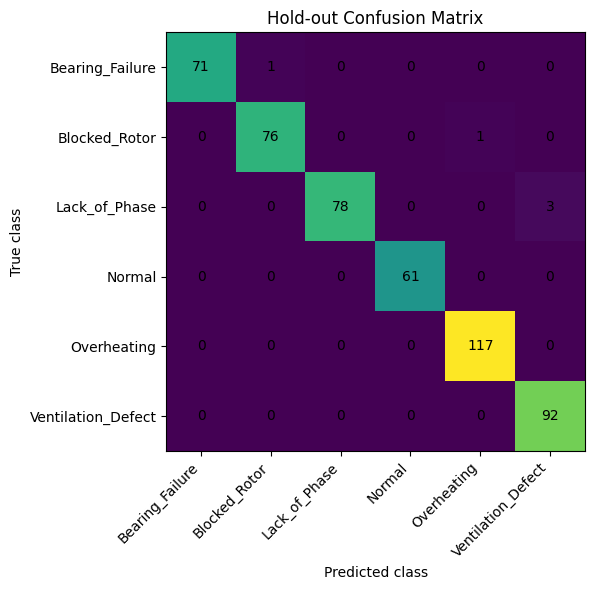


Função criada:
predict_for_rag("/content/imagem.jpg")

PROCESSAMENTO FINALIZADO
Resultados locais: /content/shufflenet_5fold_checkpoints
ZIP local: /content/ShuffleNet_5Fold_Resultados.zip
ZIP salvo no Drive: /content/drive/MyDrive/ShuffleNet_5Fold_Resultados/ShuffleNet_5Fold_Resultados.zip
Modelo final: /content/shufflenet_5fold_checkpoints/shufflenet_best_model.pth


In [21]:
# ============================================================
# PÓS-TREINAMENTO COMPLETO
# 5-FOLD SUMMARY + HOLD-OUT + CONFIDENCE + EXPORT
# Execute SOMENTE depois que os cinco folds terminarem
# ============================================================

import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Pastas
# ------------------------------------------------------------

RESULTS_DIR = Path("/content/shufflenet_5fold_checkpoints")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_RESULTS_DIR = Path(
    "/content/drive/MyDrive/ShuffleNet_5Fold_Resultados"
)
DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Consolidar os resultados dos 5 folds
# ------------------------------------------------------------

if "fold_results_df" not in globals():
    if "fold_results" in globals() and len(fold_results) > 0:
        fold_results_df = pd.DataFrame(fold_results)
    else:
        csv_path = RESULTS_DIR / "five_fold_results.csv"

        if csv_path.exists():
            fold_results_df = pd.read_csv(csv_path)
        else:
            raise RuntimeError(
                "Os resultados dos folds não foram encontrados."
            )

display(fold_results_df)

metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "mean_predicted_confidence"
]

summary_rows = []

for metric in metric_columns:
    if metric in fold_results_df.columns:
        values = fold_results_df[metric].astype(float)

        summary_rows.append({
            "metric": metric,
            "mean": values.mean(),
            "std": values.std(ddof=1),
            "min": values.min(),
            "max": values.max()
        })

five_fold_summary_df = pd.DataFrame(summary_rows)

print("\nResumo dos 5 folds")
display(five_fold_summary_df)

fold_results_df.to_csv(
    RESULTS_DIR / "five_fold_results.csv",
    index=False
)

five_fold_summary_df.to_csv(
    RESULTS_DIR / "five_fold_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Identificar o melhor fold
# ------------------------------------------------------------

best_row = fold_results_df.loc[
    fold_results_df["accuracy"].idxmax()
]

best_fold = int(best_row["fold"])

best_checkpoint_path = (
    RESULTS_DIR /
    f"shufflenet_v2_x0_5_fold_{best_fold}.pth"
)

if not best_checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint não encontrado: {best_checkpoint_path}"
    )

print("\nMelhor fold:", best_fold)
print("Validation Accuracy:", f"{best_row['accuracy']:.4f}")
print("Checkpoint:", best_checkpoint_path)

# ------------------------------------------------------------
# 4. Carregar o melhor modelo
# ------------------------------------------------------------

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

best_model = create_shufflenet_model()
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# 5. Função de avaliação genérica
# ------------------------------------------------------------

@torch.no_grad()
def evaluate_complete(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

    return {
        "loss": running_loss / total_samples,
        "labels": np.asarray(all_labels),
        "predictions": np.asarray(all_predictions),
        "probabilities": np.asarray(all_probabilities)
    }

# ------------------------------------------------------------
# 6. Avaliação no hold-out de 500 imagens
# ------------------------------------------------------------

holdout_output = evaluate_complete(
    model=best_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

y_true = holdout_output["labels"]
y_pred = holdout_output["predictions"]
y_prob = holdout_output["probabilities"]

predicted_confidence = y_prob.max(axis=1)

holdout_metrics = {
    "best_fold": best_fold,
    "loss": holdout_output["loss"],
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),
    "recall_macro": recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),
    "f1_macro": f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),
    "mean_confidence": predicted_confidence.mean(),
    "std_confidence": predicted_confidence.std(ddof=1),
    "test_samples": len(y_true)
}

holdout_metrics_df = pd.DataFrame([holdout_metrics])

print("\nResultados do teste hold-out")
display(holdout_metrics_df)

print("\nClassification report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

holdout_metrics_df.to_csv(
    RESULTS_DIR / "holdout_test_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# 7. Salvar previsões, confiança e probabilidades
# ------------------------------------------------------------

holdout_predictions_df = pd.DataFrame(
    y_prob,
    columns=[
        f"probability_{class_name}"
        for class_name in class_names
    ]
)

holdout_predictions_df.insert(
    0,
    "true_class",
    [class_names[index] for index in y_true]
)

holdout_predictions_df.insert(
    1,
    "predicted_class",
    [class_names[index] for index in y_pred]
)

holdout_predictions_df.insert(
    2,
    "predicted_confidence",
    predicted_confidence
)

holdout_predictions_df.to_csv(
    RESULTS_DIR / "holdout_test_predictions.csv",
    index=False
)

# ------------------------------------------------------------
# 8. Matriz de confusão
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(cm)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Hold-out Confusion Matrix")

for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        ax.text(
            column,
            row,
            str(cm[row, column]),
            ha="center",
            va="center"
        )

fig.tight_layout()

fig.savefig(
    RESULTS_DIR / "holdout_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9. Inferência para integração CNN -> RAG -> SLM
# ------------------------------------------------------------

inference_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

@torch.no_grad()
def predict_for_rag(
    image_path,
    model=best_model,
    top_k=3
):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Imagem não encontrada: {image_path}"
        )

    image = Image.open(image_path).convert("RGB")

    image_tensor = (
        inference_transform(image)
        .unsqueeze(0)
        .to(device)
    )

    model.eval()

    logits = model(image_tensor)
    probabilities = torch.softmax(logits, dim=1)[0]

    top_k = min(top_k, len(class_names))

    top_probabilities, top_indices = torch.topk(
        probabilities,
        k=top_k
    )

    result = {
        "predicted_fault": class_names[
            int(top_indices[0].item())
        ],
        "cnn_confidence": float(
            top_probabilities[0].item()
        ),
        "top3_predictions": [
            {
                "class": class_names[int(index.item())],
                "probability": float(probability.item())
            }
            for probability, index in zip(
                top_probabilities,
                top_indices
            )
        ]
    }

    return result

print("\nFunção criada:")
print(
    'predict_for_rag("/content/imagem.jpg")'
)

# ------------------------------------------------------------
# 10. Salvar metadados do modelo final
# ------------------------------------------------------------

final_model_path = RESULTS_DIR / "shufflenet_best_model.pth"

torch.save(
    {
        "best_fold": best_fold,
        "model_state_dict": checkpoint["model_state_dict"],
        "class_names": class_names,
        "class_to_idx": full_dataset.class_to_idx,
        "image_size": [64, 64],
        "architecture": "shufflenet_v2_x0_5",
        "pretrained_weights": "ImageNet",
        "frozen_feature_extractor": True,
        "holdout_metrics": holdout_metrics
    },
    final_model_path
)

# ------------------------------------------------------------
# 11. Compactar resultados
# ------------------------------------------------------------

archive_path = shutil.make_archive(
    base_name="/content/ShuffleNet_5Fold_Resultados",
    format="zip",
    root_dir=RESULTS_DIR
)

drive_archive_path = (
    DRIVE_RESULTS_DIR /
    "ShuffleNet_5Fold_Resultados.zip"
)

shutil.copy2(
    archive_path,
    drive_archive_path
)

print("\n" + "=" * 70)
print("PROCESSAMENTO FINALIZADO")
print("=" * 70)

print("Resultados locais:", RESULTS_DIR)
print("ZIP local:", archive_path)
print("ZIP salvo no Drive:", drive_archive_path)
print("Modelo final:", final_model_path)

In [22]:
# ============================================================
# COMPACTAR TODA A PASTA DE RESULTADOS
# ============================================================

import shutil
from google.colab import files

RESULTS_FOLDER = "/content/shufflenet_5fold_checkpoints"

ZIP_NAME = "/content/ShuffleNet_5Fold_Backup"

archive = shutil.make_archive(
    ZIP_NAME,
    "zip",
    RESULTS_FOLDER
)

print("Backup criado:")
print(archive)

files.download(archive)

Backup criado:
/content/ShuffleNet_5Fold_Backup.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# test_dl.dataset.dataset.class_to_idx


In [ ]:
# classes = ['Bearing_failure', 'Lack_of_phase', 'Normal', 'Overheating', 'Ventilation_defect', 'blocked_rotor']


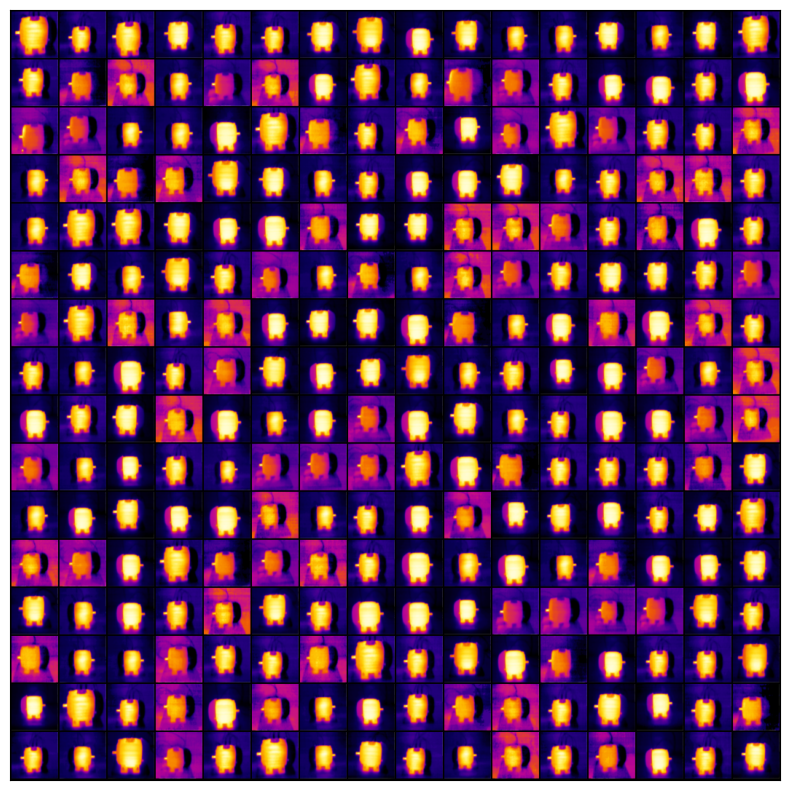

In [ ]:
def show_batch(dl):
    """Plot images grid of single batch"""
    for images, labels in dl:
        fig,ax = plt.subplots(figsize = (14,10))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images,nrow=16).permute(1,2,0))
        plt.show()
        break

show_batch(train_dl)


In [ ]:
# Load the model (download if not already present)
model = torchvision.models.shufflenet_v2_x0_5(pretrained=True)

print(model)


ShuffleNetV2(
  (conv1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (stage2): Sequential(
    (0): InvertedResidual(
      (branch1): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_

/home/jorge/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jorge/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X0_5_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Set the existing feature extraction layers to read-only
#( congela todos os pesos, exeto os pesos da ultima camada que vai ser alterada)
for param in model.parameters():
    param.requires_grad = False

# Replace the prediction layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 6)

# Now print the full model, which will include the feature extraction layers of the base model and our prediction layer
print(model)


ShuffleNetV2(
  (conv1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (stage2): Sequential(
    (0): InvertedResidual(
      (branch1): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_

In [ ]:
# Define the training function
def train(model, device, train_loader, optimizer, criterion):
    train_loss,train_correct=0.0,0
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        train_correct += pred.eq(target.view_as(pred)).sum().item()

    train_loss /= len(train_loader.sampler)
    train_accuracy = train_correct / len(train_loader.sampler)

    return train_loss, train_accuracy


In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()


29

In [ ]:
y_pred_list = []
y_true_list = []

def test(model, device, test_loader):
    # Switch the model to evaluation mode (so we don't backpropagate or drop)
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        batch_count = 0
        for data, target in test_loader:
            batch_count += 1
            data, target = data.to(device), target.to(device)

            # Get the predicted classes for this batch
            output = model(data)

            # Calculate the loss for this batch
            test_loss += loss_criteria(output, target).item()

            # Calculate the accuracy for this batch
            _, predicted = torch.max(output.data, 1)
            correct += torch.sum(target==predicted).item()

            y_pred_list.append(predicted.cpu().numpy())
            y_true_list.append(target.cpu().numpy())

    # Calculate the average loss and total accuracy for this epoch
    avg_loss = test_loss/len(test_loader.sampler)
    print('Test set: Average loss: {:.6f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        avg_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    # return average loss for the epoch
    return avg_loss

# Create an instance of the model class and allocate it to the device
model = model.to(device)

# Use an "Adam" optimizer to adjust weights
# (see https://pytorch.org/docs/stable/optim.html#algorithms for details of supported algorithms)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Specify the loss criteria
loss_criteria = nn.CrossEntropyLoss()

# Track metrics in these arrays
epoch_nums = []
training_loss = []
training_acc = []


# Train over 3 epochs (in a real scenario, you'd likely use many more)
epochs = 100
for epoch in range(1, epochs + 1):
        print(f'epoch: {epoch}')
        train_loss, train_acuracy = train(model, device, train_dl, optimizer, loss_criteria)
        print(f'Acuracy: {train_acuracy}')
        epoch_nums.append(epoch)
        training_acc.append(train_acuracy)
        training_loss.append(train_loss)

test(model, device, test_dl)


epoch: 1
Acuracy: 0.4831899921813917
epoch: 2
Acuracy: 0.7912431587177482
epoch: 3
Acuracy: 0.8444096950742768
epoch: 4
Acuracy: 0.8764659890539483
epoch: 5
Acuracy: 0.890539483971853
epoch: 6
Acuracy: 0.9007036747458952
epoch: 7
Acuracy: 0.9108678655199375
epoch: 8
Acuracy: 0.9225957779515246
epoch: 9
Acuracy: 0.9327599687255669
epoch: 10
Acuracy: 0.9351055512118843
epoch: 11
Acuracy: 0.9491790461297889
epoch: 12
Acuracy: 0.9507427677873339
epoch: 13
Acuracy: 0.9640344018764659
epoch: 14
Acuracy: 0.9687255668491008
epoch: 15
Acuracy: 0.9718530101641908
epoch: 16
Acuracy: 0.9718530101641908
epoch: 17
Acuracy: 0.9741985926505082
epoch: 18
Acuracy: 0.9734167318217357
epoch: 19
Acuracy: 0.982017200938233
epoch: 20
Acuracy: 0.9827990617670055
epoch: 21
Acuracy: 0.9812353401094606
epoch: 22
Acuracy: 0.9851446442533229
epoch: 23
Acuracy: 0.9851446442533229
epoch: 24
Acuracy: 0.9843627834245504
epoch: 25
Acuracy: 0.9882720875684128
epoch: 26
Acuracy: 0.9859265050820953
epoch: 27
Acuracy: 0.98

0.0006866241991519928

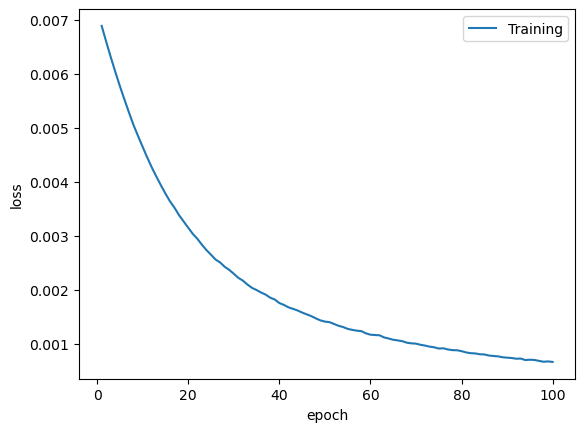

In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt

plt.plot(epoch_nums, training_loss)
#plt.plot(epoch_nums, validation_loss)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Training'], loc='upper right')
plt.show()


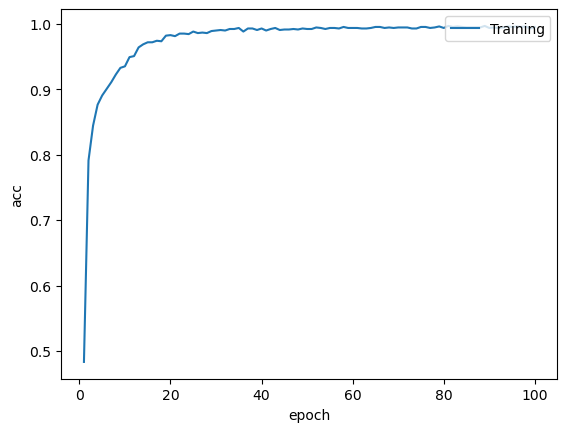

In [ ]:
plt.plot(epoch_nums, training_acc)
#plt.plot(epoch_nums, validation_loss)
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend(['Training'], loc='upper right')
plt.show()


In [ ]:
y_pred_list = np.concatenate(y_pred_list)
y_true_list = np.concatenate(y_true_list)


In [ ]:
y_true_list


array([5, 0, 1, 2, 2, 3, 5, 3, 3, 3, 5, 0, 1, 3, 1, 5, 2, 3, 1, 1, 4, 5,
       1, 3, 3, 3, 4, 4, 3, 4, 4, 4, 1, 2, 1, 1, 1, 2, 5, 3, 4, 3, 2, 1,
       5, 2, 2, 0, 4, 5, 2, 5, 2, 5, 2, 4, 3, 4, 0, 2, 3, 4, 5, 5, 0, 3,
       4, 3, 1, 3, 3, 2, 1, 5, 5, 2, 1, 3, 3, 4, 5, 3, 5, 0, 2, 5, 1, 3,
       1, 0, 2, 5, 1, 3, 4, 3, 4, 0, 1, 5, 3, 3, 2, 3, 4, 0, 5, 0, 4, 0,
       0, 0, 5, 1, 2, 4, 5, 3, 2, 1, 2, 5, 3, 3, 2, 0, 1, 5, 3, 4, 1, 4,
       2, 3, 0, 4, 3, 0, 0, 4, 5, 5, 0, 5, 3, 4, 5, 3, 1, 1, 1, 1, 5, 3,
       4, 3, 3, 5, 3, 0, 5, 4, 4, 4, 1, 3, 4, 2, 5, 1, 4, 5, 5, 5, 3, 4,
       2, 2, 3, 4, 5, 0, 3, 5, 2, 0, 4, 0, 1, 0, 5, 2, 5, 3, 1, 5, 2, 3,
       5, 4, 3, 3, 2, 4, 0, 1, 5, 0, 2, 2, 1, 5, 1, 3, 1, 4, 0, 2, 4, 5,
       1, 2, 0, 2, 1, 4, 0, 0, 2, 3, 4, 2, 3, 1, 1, 0, 0, 1, 5, 3, 0, 3,
       2, 5, 2, 0, 5, 1, 3, 3, 1, 3, 2, 4, 4, 2, 0, 0, 4, 0, 5, 5, 0, 4,
       0, 1, 5, 3, 4, 1, 4, 5, 0, 3, 1, 1, 5, 1, 5, 3, 3, 1, 1, 3, 0, 1,
       1, 3, 1, 3, 4, 3, 5, 4, 1, 4, 2, 0, 0, 3, 1,

In [ ]:
y_pred_list


array([5, 0, 1, 2, 2, 3, 5, 3, 3, 3, 5, 0, 1, 3, 1, 5, 2, 3, 1, 1, 4, 5,
       1, 3, 3, 3, 4, 4, 3, 4, 4, 4, 1, 2, 1, 1, 1, 2, 5, 3, 4, 3, 2, 1,
       5, 2, 2, 0, 4, 5, 2, 5, 2, 5, 2, 4, 3, 4, 0, 2, 3, 4, 5, 5, 0, 3,
       4, 3, 1, 3, 3, 2, 1, 5, 5, 2, 1, 3, 3, 4, 5, 3, 5, 0, 2, 5, 1, 3,
       1, 0, 2, 5, 1, 3, 4, 3, 4, 0, 1, 5, 3, 3, 2, 3, 4, 0, 5, 0, 4, 0,
       0, 0, 5, 1, 2, 4, 5, 3, 2, 1, 2, 5, 3, 3, 2, 0, 4, 5, 3, 4, 1, 4,
       2, 3, 0, 4, 3, 0, 0, 4, 5, 5, 0, 5, 3, 4, 5, 3, 1, 1, 1, 1, 5, 3,
       4, 3, 3, 5, 3, 0, 5, 4, 4, 4, 1, 3, 4, 2, 5, 1, 4, 5, 5, 5, 3, 4,
       2, 2, 3, 4, 5, 0, 3, 5, 2, 0, 4, 0, 1, 0, 5, 2, 5, 3, 1, 5, 2, 3,
       5, 4, 3, 3, 2, 4, 0, 1, 5, 0, 2, 2, 1, 5, 1, 3, 1, 4, 0, 2, 4, 5,
       1, 2, 0, 2, 1, 4, 0, 0, 2, 3, 4, 2, 3, 1, 1, 0, 0, 1, 5, 3, 0, 3,
       2, 5, 2, 0, 5, 1, 3, 3, 1, 3, 2, 4, 4, 2, 0, 0, 4, 0, 5, 5, 0, 4,
       0, 1, 5, 3, 4, 1, 4, 5, 0, 3, 1, 1, 5, 1, 5, 3, 3, 1, 1, 3, 0, 1,
       1, 3, 1, 3, 4, 3, 5, 4, 1, 4, 2, 0, 0, 3, 1,

In [ ]:
len(y_true_list)


500

In [ ]:
print(classification_report(y_true_list, y_pred_list, target_names=classes))


                    precision    recall  f1-score   support

   Bearing_failure       1.00      1.00      1.00        75
     Lack_of_phase       1.00      0.98      0.99        87
            Normal       1.00      1.00      1.00        62
       Overheating       0.99      1.00      1.00       107
Ventilation_defect       0.98      1.00      0.99        88
     blocked_rotor       1.00      0.99      0.99        81

          accuracy                           0.99       500
         macro avg       0.99      0.99      0.99       500
      weighted avg       0.99      0.99      0.99       500



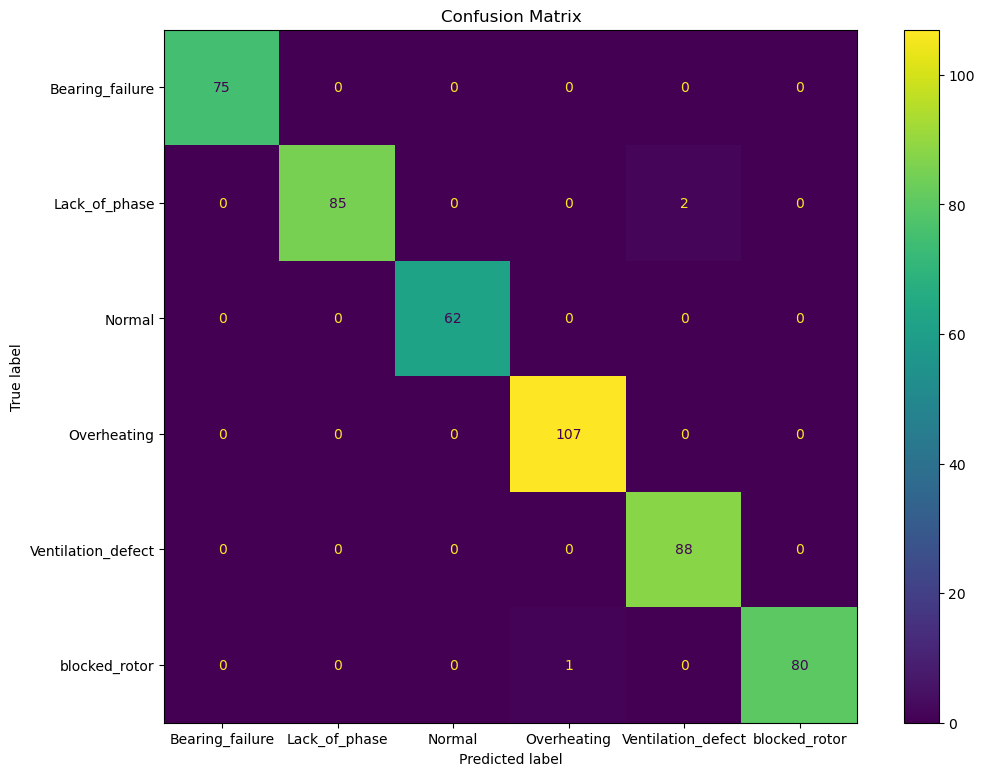

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (12, 9)

cm = confusion_matrix(y_true_list, y_pred_list)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot()
plt.title('Confusion Matrix')
plt.savefig("Confusion_Matrix.png")
plt.show()


In [ ]:
torch.save(model, 'shufflenet_v2_treinada_FINAL.pth')
